ESEMPIO PRATICO: AUTOENCODER SU CIFAR10 CON KERAS

Il mondo reale è a colori, pertanto oggi passiamo dal bianco e nero alla complessità cromatica del dataset cifar10.
Vediamo come una macchina pensa il colore e come non farle dimenticare i dettagli fondamentale durante la compressione.

- Data Preparation: gestione dei canali RGN e tensori colorati
- Architettura del Bottleneck: punto di perfetto tra sintesi e fedeltà
- Ottimizzazione e Loss: MSE e MAE

Primo ostacolo: la dimensionalità del segnale naturale

Passare grigio a un immagine colorata, non abbiamo più solo una matrice di intensità luminusa, abbiamo la luce ma anche il rosso il verde ed il blu.
Con i colori la complessità del segnale aumenta di 3 volte rispetto al grigio.

Ma come gestiamo queste immagini in modo che l'autoencoder possa masticare?

Normalizzazione e Shape dei Tensori
Preparare il segnale multi-canale
- Preparazione dataset tramite keras.detasets.cifra10 con separazione automatica tra training set e test set
- Normalizzazione dei pixel, intervallo 0 e 1, dividendo i valori per 255 per stabilizzare il gradiente.
- Flattening dell'immagine da un tesore 3D a un vettore 1D per l'uso in autoencoder densi stanrdard. Dobbiamo srotolare le nostre immagini 3D in lunghi vettori monodimensionali. Riscaliamo ogni singolo valore per garantire che il gradiente non epsloda durante l'addestramento.
- La forma dell'input per ogni campione passa da un singolo piano a un volume di dati interconnessi

Ma la bellezza del colore porta con se sfide inaspettate.

Sfide del Segnale Naturale
Lavorare con immagini naturali significa combattere contro il rumore, a differenza dei numeri di MINST dove lo sfondo è un vuoto nero perfetto,in CIFAR10 abbiamo cieli, erba e texture complesse, il modello deve fare un sfotzo maggiore, deve capire che un pixel rosso fa parte di una macchina e non di un fiore.
Complessità cromatica: le variazioni di colore aggiungono dimensioni semantiche che il modello deve imparare a correlare durante la compressione
Rapporto Segnale-Rumore: le immagini naturali contengono sfondi complessi e texture che rendono la ricostruzione più difficile rispetto ai tratti isolati dei numeri
Memoria e Tensori: la gestione di 3072 (32x32x3) feature per immagine richiede una struttura di rete più capace rispetto ai 784 pixel del MNIST (in scala di grigi)

Visualizzare il Volume dei Dati
Dalla matrice al cubo informativo
Ogni immagine è un cubo di dati, per ogni singola piccola immagine la nostra rete deve processare oltre 3.072 caratteristiche sumultaneamente
Se pensi che il dataset ha oltre 50.000 immagini si può capire l'impegno computazionale.
Ogni pixel è ora un vettore di 3 intensità (RGB).
Input dim = 32x32x3
immagini da 32x32 a colori (RGB)
Il pre-processing non è solo una pulizia dati, ma la definizione dello spazio vettoriale in cui il nostro Autoencoder dovrà operare.

Ora che i dati sono pronti, costruiamo la strettoia dell'architettura

La calibrazione del Bottleneck
Il cuore dell'Autoencoder risiede nella dimensione del suo spazio latente. Decidiamo quanto vogliamo sacrificare in termini di dettaglio per ottenere sintesi.
La scelta del numero di neuroni nel bottleneck influenza direttamente la capacità del decoder di ripristinare i colori originali. 

Ma come calibriamo questa decisoine

Trade-off Dimesionale
- Se rendiamo lo spazio latente troppo piccolo il decoer non avrà informaizoni per ricostruire i colori originali, perdendo la coerenza cromatica dell'immagine originale
- Al contrario, se lo spazio latente è troppo grande, la rete diventerà pigra e si limiterà a copiare i pixel senza capirne il motivo
- L'uso dell'API Funcional di Keras permette di definire encoder e decoder come modelli separati ma integrati
- Il rapporto di compressione è la misura della nostra ambizione algoritmica. 

Ma oltre alla dimensione contano anche gli strumenti di attivazione

Iperparametri della Struttura
Funzioni di Attivazione
L'uso di ReLu negli stati intermedi/interni accellera l'apprendimento 
Mentre la Sigmoide in uscita/ultimo strato perchè vogliamo che ogni pixel ricostruito torni nel range 0 e 1 che abbiamo definito all'inizio
Capactià semantica
Lo spazio latente deve essere sufficientemente ampio da catturare non solo la forma degli oggetti, ma anche le loro proprietà cromatiche dominanti.

Studio del Vettore Latente
L'impronta digitale dell'immagine
Variare la dimensione latente da 128 a 512 neuroni cambia drasticamente la nitidezza delle ricostruioni su CIFAR-10. Come dare ad un artista un set di pennelli molto più fini.
Il bottleneck non è solo un limite fisico, ma un regolatore di intelligenza che forza la rete a trovare pattern comuni tra classi diverse.
E' qui che il modello impara la grammatica delle immagini.

Ma come faccimao a dire alla rete se sta disegnando bene o male?
Parliamo di ottimizzazione

Analisi dell'Ottmizzazione
Dinamiche di addestramento e funzioni di perdita
Come diciamo se una ricostruzione è buona?
La funzione di perdita guida ogni singolo aggiornamento dei pesi, analiziamo come il valore del tasso di apprendimento possa rnedere la ricostruzione stabile oppure instabile e rumorosa.

Funzioni di perdita
MSE vs MAE
- Il Mean Square Erroe (MSE) penalizza fortemente le grandi differenze, tendendo a produrre ricostruzioni medie e talvolta sfuocate. Se un pixel è molto diverso dall'originale lo penalizza fortemente. Questo porta a immagini sfuocate
- Il Mean Absolute Error (MAE) è più robusto agli outlier e può preservare meglio certi contrasti cromatici netti. A volte riesce a preservare i contrasti netti.
- Il Learning Rate determina la velocità con cui i pesi si adattano alla distribuzione naturale delle immagini di CIFAR
- L'ottimizzatore Adam bilancia dinamicamente il momentum per navigare la complessa superficie della loss a 3072 dimensioni

Scegliere tra MSE vs MAE cambia radicalmente l'aspetto dei risultati.
Come monitoriamo questo processo?

Monitoraggio del Trainig
Dobbiamo stare attenti soprattutto al overfitting del Decoder. Identificare quando la rete smette di imparare feature generali e inizia a memorizzare il rumore del dataset di training.
Poichè la loss numerica non sempre rifletta la qualità percepita: l'importanza del plotting e la valutazione visiva, rimangono fondamentali. Plottare periodicamente i risultati
All'inizio la rete impara forme e ombre (luminanza), come guardare il monto attraverso un vetro appannato, e solo successivamente i colori (crominanza).

Ma cosa ci insergna questo sulla nostra capacità di percepire l'errore?
Dall'Errore alla Percezione
Nelle immagini naturali, l'errore di ricostruzione del colore può essere più evidente di un errore nella forma: questo fenomeno è analizzabile anche nel codice.
Il successo dell'ottimizzazione si misura nella capacità del modello ad essere coerente cromaticamente, analizzando il test set (immagini mai viste prima)

Per risolvere il problema della qualità del dato sono nate delle strategie più avanzate che vedremomo in seguito.

Operazione: Addestramento ottimizzato tramite MSE
Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 0.0352 - val_loss: 0.0247
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 0.0206 - val_loss: 0.0169
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - loss: 0.0157 - val_loss: 0.0150
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - loss: 0.0141 - val_loss: 0.0141
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.0133 - val_loss: 0.0132
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.0127 - val_loss: 0.0125
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.0124 - val_loss: 0.0121
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.0120 - val_loss: 0.0120
Epoch 9/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.0118 - val_loss: 0.0118
Epoch 10/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - loss: 0.0116 - val_loss: 0.0117
Epoch 11/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - loss: 0.0115

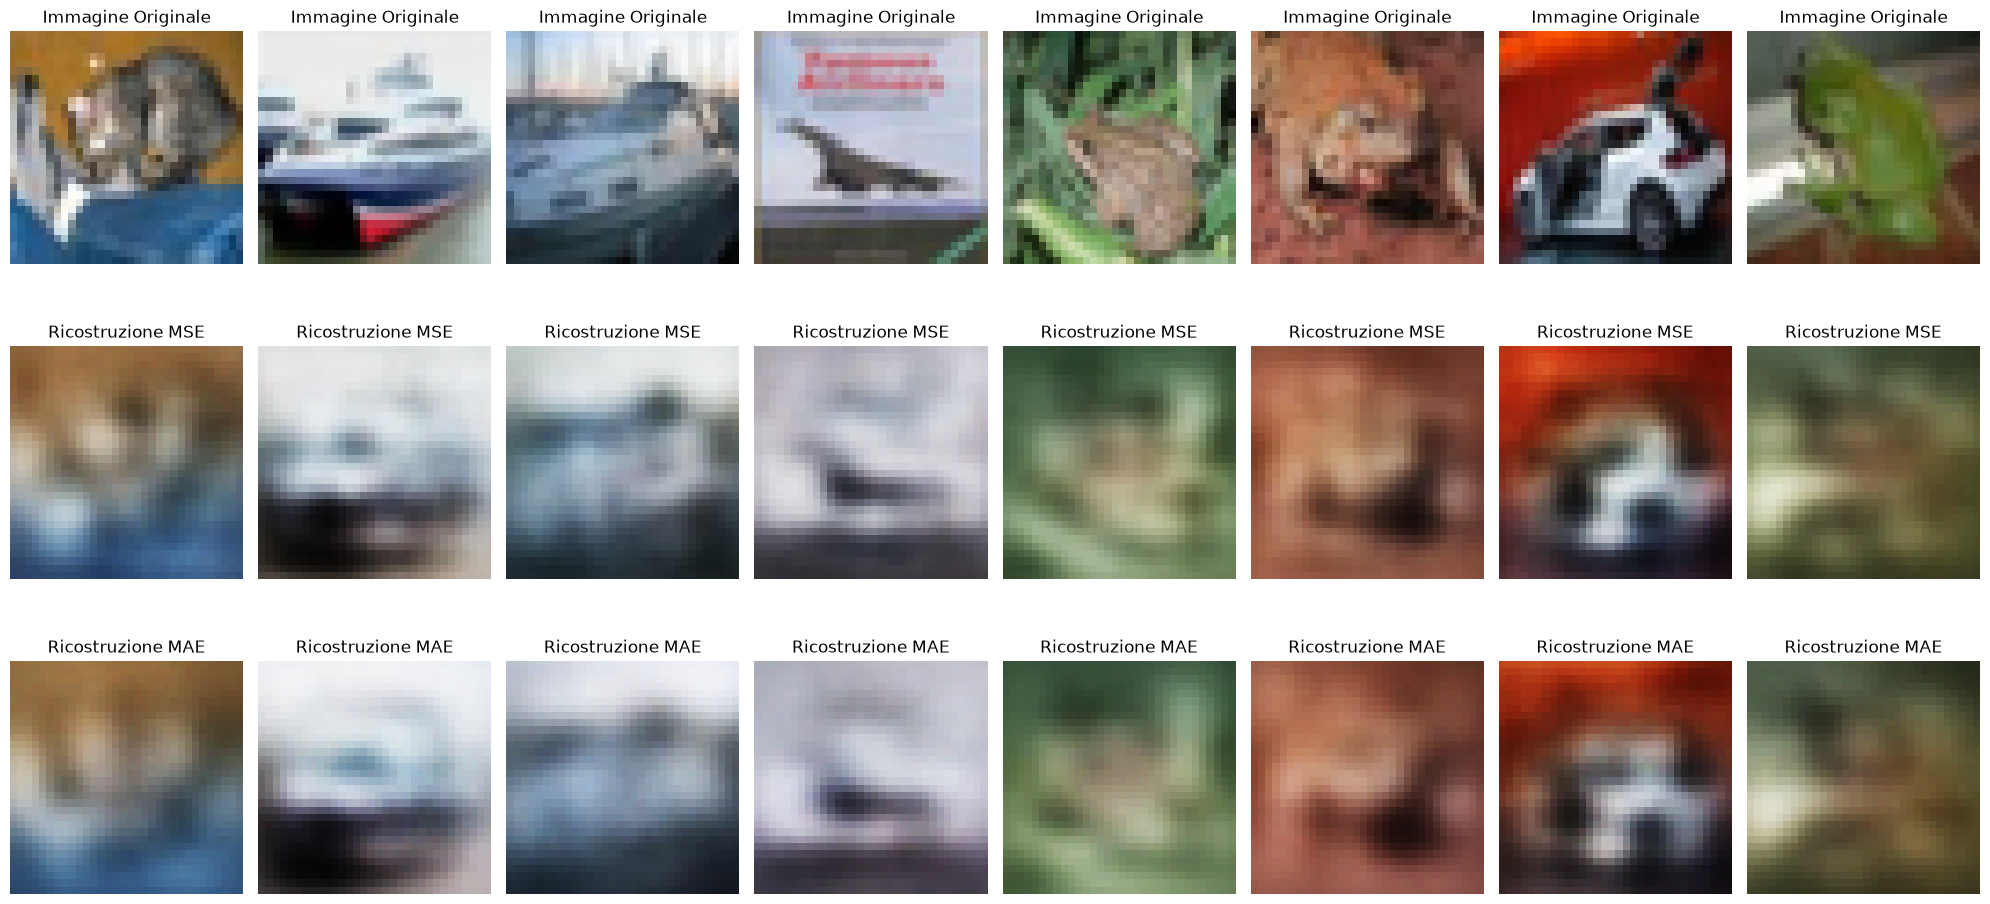

: 

In [ ]:
import os

# Per garantire la massima compatibilità e sfruttare le ottimizzazioni di calcolo più recenti,
# impostiamo il backend di Keras su "torch" (PyTorch) prima di importare la libreria.
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------------------
# FASE 1: ACQUISIZIONE E PREPARAZIONE DEL DATASET CIFAR-10
# -----------------------------------------------------------------------------------------

# Utilizziamo le utility integrate di Keras per scaricare il dataset CIFAR-10.
# Questo dataset contiene 60.000 immagini a colori 32x32, divise in 10 categorie.
# Carichiamo solo le immagini (x) ignorando le etichette (_), poiché l'autoencoder 
# apprende a ricostruire l'input stesso, agendo quindi in modalità non supervisionata.
(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

# Le immagini originali hanno pixel con valori tra 0 e 255 (formato unit8).
# Per facilitare la convergenza dell'algoritmo di addestramento, convertiamo i dati 
# in virgola mobile (float32) e normalizziamo i valori nell'intervallo [0, 1].
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Calcoliamo la dimensione totale dell'input: 32 pixel di altezza * 32 di larghezza * 3 canali RGB.
# Il risultato è 3072, che rappresenterà il numero di neuroni dello strato di input.
input_dim = 32 * 32 * 3

# Poiché utilizzeremo strati "Dense" (completamente connessi), dobbiamo trasformare 
# ogni immagine da una matrice 3D (32, 32, 3) in un vettore piatto (1D) di 3072 elementi.
x_train = x_train.reshape((len(x_train), input_dim))
x_test = x_test.reshape((len(x_test), input_dim))

# -----------------------------------------------------------------------------------------
# FASE 2: PROGETTAZIONE DELL'ARCHITETTURA DELL'AUTOENCODER
# -----------------------------------------------------------------------------------------

def build_autoencoder():
    """
    Costruisce un modello Autoencoder utilizzando la Functional API di Keras.
    L'architettura segue una struttura a 'imbuto' per comprimere e poi ricostruire i dati.
    """
    # Definiamo il punto di ingresso per il flusso di dati (tensor di input).
    input_img = keras.Input(shape=(input_dim,))
    
    # --- PARTE 1: ENCODER (Compressione) ---
    # Lo strato nascosto riduce la dimensionalità a 512 neuroni.
    # L'attivazione 'relu' introduce non-linearità per catturare pattern complessi.
    hidden_enc = layers.Dense(512, activation="relu")(input_img)
    
    # Il 'bottleneck' (collo di bottiglia) è lo strato centrale con soli 128 neuroni.
    # Qui il modello è costretto a creare una rappresentazione compressa dell'immagine.
    bottleneck = layers.Dense(128, activation="relu")(hidden_enc)
    
    # --- PARTE 2: DECODER (Ricostruzione) ---
    # Iniziamo la riespansione dei dati portandoli nuovamente a 512 neuroni.
    hidden_dec = layers.Dense(512, activation="relu")(bottleneck)
    
    # Lo strato di output riporta i dati alla dimensione originale (3072).
    # Usiamo la funzione 'sigmoid' per garantire che i valori dei pixel siano tra 0 e 1,
    # coerentemente con la normalizzazione fatta sui dati di input.
    output_img = layers.Dense(input_dim, activation="sigmoid")(hidden_dec)
    
    # Uniamo Encoder e Decoder in un unico oggetto Modello.
    return keras.Model(input_img, output_img)

# -----------------------------------------------------------------------------------------
# FASE 3: CONFIGURAZIONE E ADDESTRAMENTO CON MSE (MEAN SQUARED ERROR)
# -----------------------------------------------------------------------------------------

print("Operazione: Addestramento ottimizzato tramite MSE")

# L'errore quadratico medio (MSE) penalizza gli errori più grandi in modo esponenziale.
# Questo porta il modello a cercare di evitare grandi discrepanze, producendo spesso 
# ricostruzioni che risultano leggermente "sfocate" ma bilanciate.
model_mse = build_autoencoder()
model_mse.compile(optimizer="adam", loss="mse")

# Addestriamo il modello passando x_train sia come input che come target desiderato.
model_mse.fit(
    x_train, x_train,
    epochs=50, 
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

# Generiamo le immagini ricostruite dal dataset di test per valutare le prestazioni.
decoded_mse = model_mse.predict(x_test)

# -----------------------------------------------------------------------------------------
# FASE 4: CONFIGURAZIONE E ADDESTRAMENTO CON MAE (MEAN ABSOLUTE ERROR)
# -----------------------------------------------------------------------------------------

print("\nOperazione: Addestramento ottimizzato tramite MAE")

# L'errore assoluto medio (MAE) tratta tutti gli errori allo stesso modo, senza elevarli al quadrato.
# È intrinsecamente più robusto verso i dati anomali (outlier) e tende a prestare più
# attenzione ai dettagli puntuali rispetto al comportamento globale del segnale.
model_mae = build_autoencoder()
model_mae.compile(optimizer="adam", loss="mae")

model_mae.fit(
    x_train, x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

# Otteniamo la seconda serie di ricostruzioni per il confronto visivo.
decoded_mae = model_mae.predict(x_test)

# -----------------------------------------------------------------------------------------
# FASE 5: VISUALIZZAZIONE COMPARATIVA E ANALISI DEI RISULTATI
# -----------------------------------------------------------------------------------------

# Selezioniamo il numero di campioni da visualizzare (8 immagini).
num_samples = 8
plt.figure(figsize=(20, 10))

for i in range(num_samples):
    # RIGA 1: Immagini originali dal dataset di test.
    # Convertiamo il vettore piatto di nuovo in formato (32, 32, 3) per Matplotlib.
    ax = plt.subplot(3, num_samples, i + 1)
    plt.imshow(x_test[i].reshape(32, 32, 3))
    plt.title("Immagine Originale")
    plt.axis("off")

    # RIGA 2: Immagini ricostruite dal modello addestrato con perdita MSE.
    ax = plt.subplot(3, num_samples, i + 1 + num_samples)
    plt.imshow(decoded_mse[i].reshape(32, 32, 3))
    plt.title("Ricostruzione MSE")
    plt.axis("off")

    # RIGA 3: Immagini ricostruite dal modello addestrato con perdita MAE.
    ax = plt.subplot(3, num_samples, i + 1 + 2 * num_samples)
    plt.imshow(decoded_mae[i].reshape(32, 32, 3))
    plt.title("Ricostruzione MAE")
    plt.axis("off")

# Ottimizziamo la spaziatura tra i grafici e mostriamo la finestra.
plt.tight_layout()
plt.show()
